In [ ]:
Uploading my csv file in colab


In [ ]:

from google.colab import files
uploaded = files.upload()

Saving ecommerce_sales_data.csv to ecommerce_sales_data.csv



Dataset Preview
> Add blockquote



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10,6)

df = pd.read_csv('ecommerce_sales_data.csv')
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit
0,2024-12-31,Printer,Office,North,4,3640,348.93
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73
3,2024-03-16,Mouse,Accessories,South,2,786,202.87
4,2022-09-10,Mouse,Accessories,West,1,509,103.28


Dataset Check

In [ ]:
df.info()
print("Shape:", df.shape)
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3500 entries, 0 to 3499
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    3500 non-null   object 
 1   Product Name  3500 non-null   object 
 2   Category      3500 non-null   object 
 3   Region        3500 non-null   object 
 4   Quantity      3500 non-null   int64  
 5   Sales         3500 non-null   int64  
 6   Profit        3500 non-null   float64
dtypes: float64(1), int64(2), object(4)
memory usage: 191.5+ KB
Shape: (3500, 7)


,Quantity,Sales,Profit
count,3500.000000,3500.000000,3500.000000
mean,4.931714,3047.966000,527.047203
std,2.575895,2440.213237,504.139732
min,1.000000,51.000000,6.970000
25%,3.000000,1049.500000,158.695000
50%,5.000000,2350.500000,361.070000
75%,7.000000,4537.000000,729.125000
max,9.000000,10782.000000,2946.930000


Cleanning Output (Missing values+Duplicates Remove)

In [ ]:
print(df.isnull().sum())
print("Duplicates:", df.duplicated().sum())

df = df.dropna()
df = df.drop_duplicates()
df.reset_index(drop=True, inplace=True)
print("After cleaning:", df.shape)

Order Date      0
Product Name    0
Category        0
Region          0
Quantity        0
Sales           0
Profit          0
dtype: int64
Duplicates: 0
After cleaning: (3500, 7)


Data Conversion

In [ ]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M')
df['Year'] = df['Order Date'].dt.year
df.head()

,Order Date,Product Name,Category,Region,Quantity,Sales,Profit,Month,Year
0,2024-12-31,Printer,Office,North,4,3640,348.93,2024-12,2024
1,2022-11-27,Mouse,Accessories,East,7,1197,106.53,2022-11,2022
2,2022-05-11,Tablet,Electronics,South,5,5865,502.73,2022-05,2022
3,2024-03-16,Mouse,Accessories,South,2,786,202.87,2024-03,2024
4,2022-09-10,Mouse,Accessories,West,1,509,103.28,2022-09,2022


Top selling products Analyze

In [ ]:
top_products = df.groupby('Product Name')['Sales'].sum().sort_values(ascending=False)
print(top_products)

Product Name
Camera        1177381
Monitor       1160048
Printer       1094216
Mouse         1074398
Smartphone    1069681
Smartwatch    1049211
Keyboard      1024507
Tablet        1023928
Laptop        1005873
Headphones     988638
Name: Sales, dtype: int64


Monthly Sales Trend

In [ ]:
monthly_sales = df.groupby('Month')['Sales'].sum()
print(monthly_sales)

Month
2022-01    341544
2022-02    208775
2022-03    294660
2022-04    230624
2022-05    314295
2022-06    273851
2022-07    214627
2022-08    296242
2022-09    240211
2022-10    324989
2022-11    257111
2022-12    259041
2023-01    343256
2023-02    313931
2023-03    303391
2023-04    280808
2023-05    346481
2023-06    251686
2023-07    320798
2023-08    388428
2023-09    303409
2023-10    253145
2023-11    306195
2023-12    375064
2024-01    282814
2024-02    179708
2024-03    341563
2024-04    310444
2024-05    373911
2024-06    314268
2024-07    309515
2024-08    240269
2024-09    341926
2024-10    314135
2024-11    291769
2024-12    324997
Freq: M, Name: Sales, dtype: int64


Bar chart

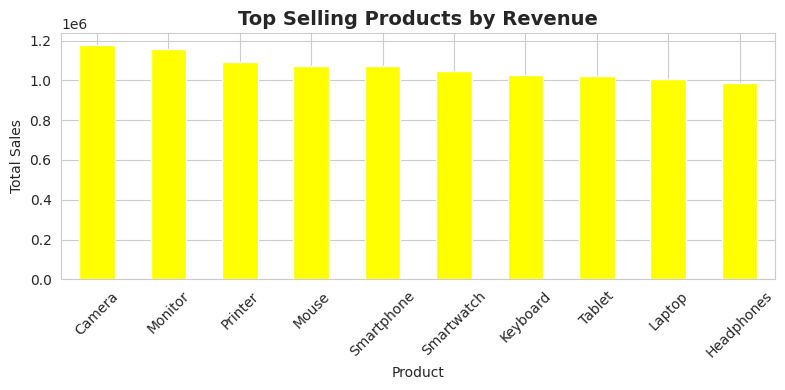

In [ ]:
plt.figure(figsize=(8,4))
top_products.plot(kind='bar', color='yellow')
plt.title('Top Selling Products by Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Product')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('top_products.png')
plt.show()

Line chart

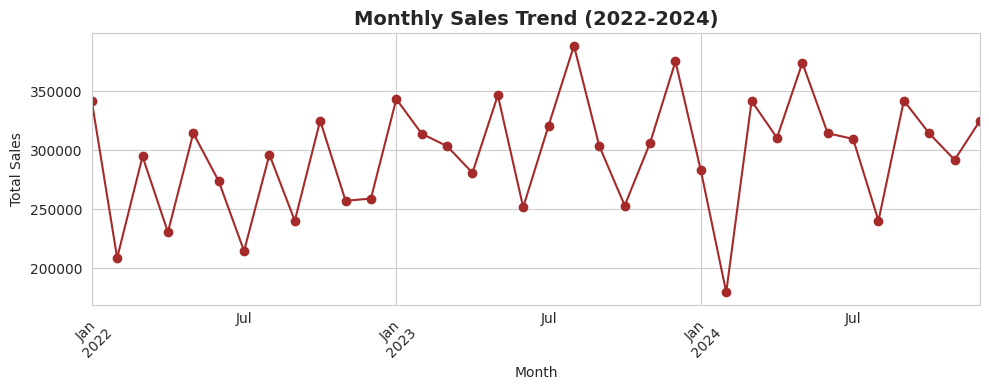

In [ ]:
plt.figure(figsize=(10,4))
monthly_sales.plot(kind='line', marker='o', color='brown')
plt.title('Monthly Sales Trend (2022-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Sales')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('monthly_trend.png')
plt.show()

Dashboard

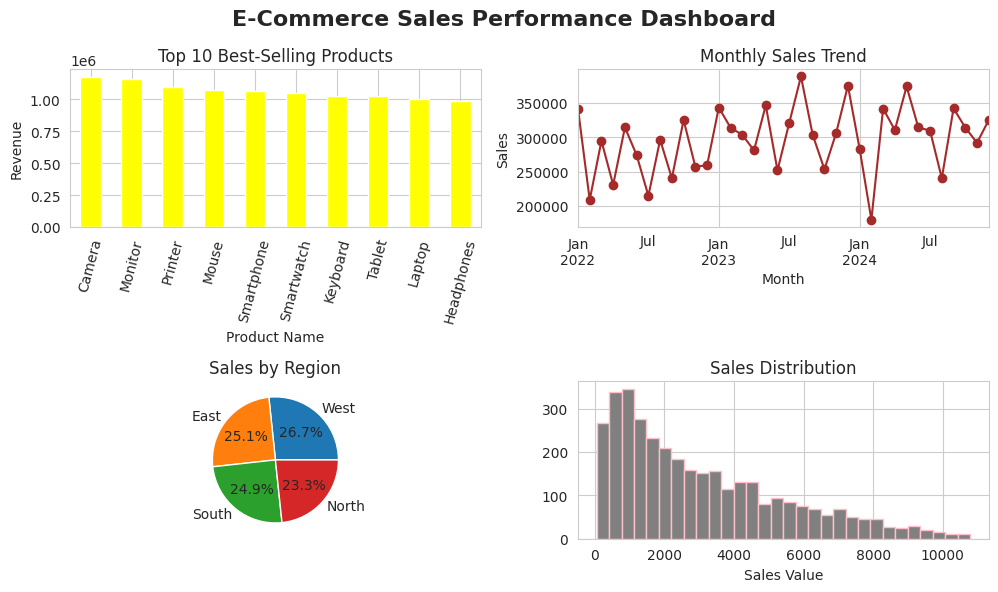

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(10,6))
fig.suptitle('E-Commerce Sales Performance Dashboard', fontsize=16, fontweight='bold')
top_products.plot(kind='bar', ax=axes[0,0], color='yellow')
axes[0,0].set_title('Top 10 Best-Selling Products')
axes[0,0].set_ylabel('Revenue')

axes[0,0].tick_params(axis='x', rotation=75)
monthly_sales.plot(kind='line', ax=axes[0,1], marker='o', color='brown')
axes[0,1].set_title('Monthly Sales Trend')
axes[0,1].set_ylabel('Sales')

region_sales = df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
axes[1,0].pie(region_sales, labels=region_sales.index, autopct='%1.1f%%')
axes[1,0].set_title('Sales by Region')
# 4. Histogram - sales distribution
axes[1,1].hist(df['Sales'], bins=30, color='gray', edgecolor='pink')
axes[1,1].set_title('Sales Distribution')
axes[1,1].set_xlabel('Sales Value')

plt.tight_layout()
plt.savefig('dashboard.png', dpi=150)
plt.show()

Key Insights

In [ ]:
print("Top 3 products:", top_products.head(3))
print("\nBest month:", monthly_sales.idxmax(), "-", monthly_sales.max())
print("\nTop region:", region_sales.idxmax())
print("\nTotal Revenue:", df['Sales'].sum())

Top 3 products: Product Name
Camera     1177381
Monitor    1160048
Printer    1094216
Name: Sales, dtype: int64

Best month: 2023-08 - 388428

Top region: West

Total Revenue: 10667881
